# Compare Surface Heat Fluxes and Sea Ice Formation

In [2]:
# packages for data processing
import numpy as np
import pandas as pd
import xarray as xr
from xmitgcm import open_mdsdataset
import gsw as gsw

# packages for plotting
import matplotlib.pyplot as plt
from matplotlib.legend import Legend
import plotly.graph_objects as go # interactive/3D plotting
import plotly.express as px
import cmocean.cm as cmo # ocean colormaps

# my own functions
from plotting_functions import *
from scientific_functions import *

# technical packages
import warnings

## Load Surface Diagnostics & Output

In [3]:

model_runs = [f"MIZ{i:03d}" for i in range(9,19)] # model runs to loop through
delta_t = 4 # time step in seconsurfDiag
output_dir = "../../MITgcm/so_plumes/"

heat_ice_df = pd.DataFrame(index = ["Q_ice", "h_ice (m)", "F_s (g/m^2s)"])

# surpress the xmitgcm warning about future changes with timedelta
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)

    for i in range(len(model_runs)):
        run = model_runs[i]
    
        # load diagnostic dataset
        surfDiag = open_mdsdataset(output_dir+run, prefix = ['surfDiag'], delta_t = delta_t, geometry = "cartesian")

        # runtime in s
        runtime = np.float64(surfDiag.time[-1]-surfDiag.time[0])/1e9

        TFLUX_mean = surfDiag.TFLUX.isel(YC=slice(0,50)).mean(dim = ["XC","YC","time"])
        surForcT_mean = surfDiag.surForcT.isel(YC=slice(0,50)).mean(dim = ["XC","YC","time"])
        Q_ice_mean = (surForcT_mean- TFLUX_mean).values

        h_ice = seaice_thickness(Q_ice=Q_ice_mean, delta_t=runtime)
        F_s = F_s_seaice(Q_ice=Q_ice_mean)

        heat_ice_df[run] = [Q_ice_mean, h_ice, F_s]
        
heat_ice_df

,MIZ009,MIZ010,MIZ011,MIZ012,MIZ013,MIZ014,MIZ015,MIZ016,MIZ017,MIZ018
Q_ice,-63.240871535950305,-1.5571568078302107,-500.86248130783014,-97.83978893409937,-33.70144084096353,-364.41296405224807,0.0,-3.7039399166048383,-62.573865122379004,-115.71850154874033
h_ice (m),0.047557,0.001171,0.376649,0.073576,0.025343,0.274039,-0.0,0.002785,0.047056,0.08702
F_s (g/m^2s),-0.007589,-0.000187,-0.060103,-0.011741,-0.004044,-0.04373,0.0,-0.000444,-0.007509,-0.013886


In [93]:
# ref run compared to no supercooling (MIZ014):
delta_Q = heat_ice_df.loc["Q_ice", "MIZ009"]-heat_ice_df.loc["Q_ice", "MIZ014"] 
delta_h_ice = heat_ice_df.loc["h_ice (m)", "MIZ009"]-heat_ice_df.loc["h_ice (m)", "MIZ014"]
print(f"In the supercooling simulation, the ocean lost {delta_Q:.0f} W/m²s more heat compared to without supercooling. This results to {delta_Q*48*3.6/1000:.0f} MJ/m².")
print(f"and {delta_h_ice:.2f} m less sea ice were formed")

In the supercooling simulation, the ocean lost 301 W/m²s more heat compared to without supercooling. This results to 52 MJ/m².
and -0.23 m less sea ice were formed


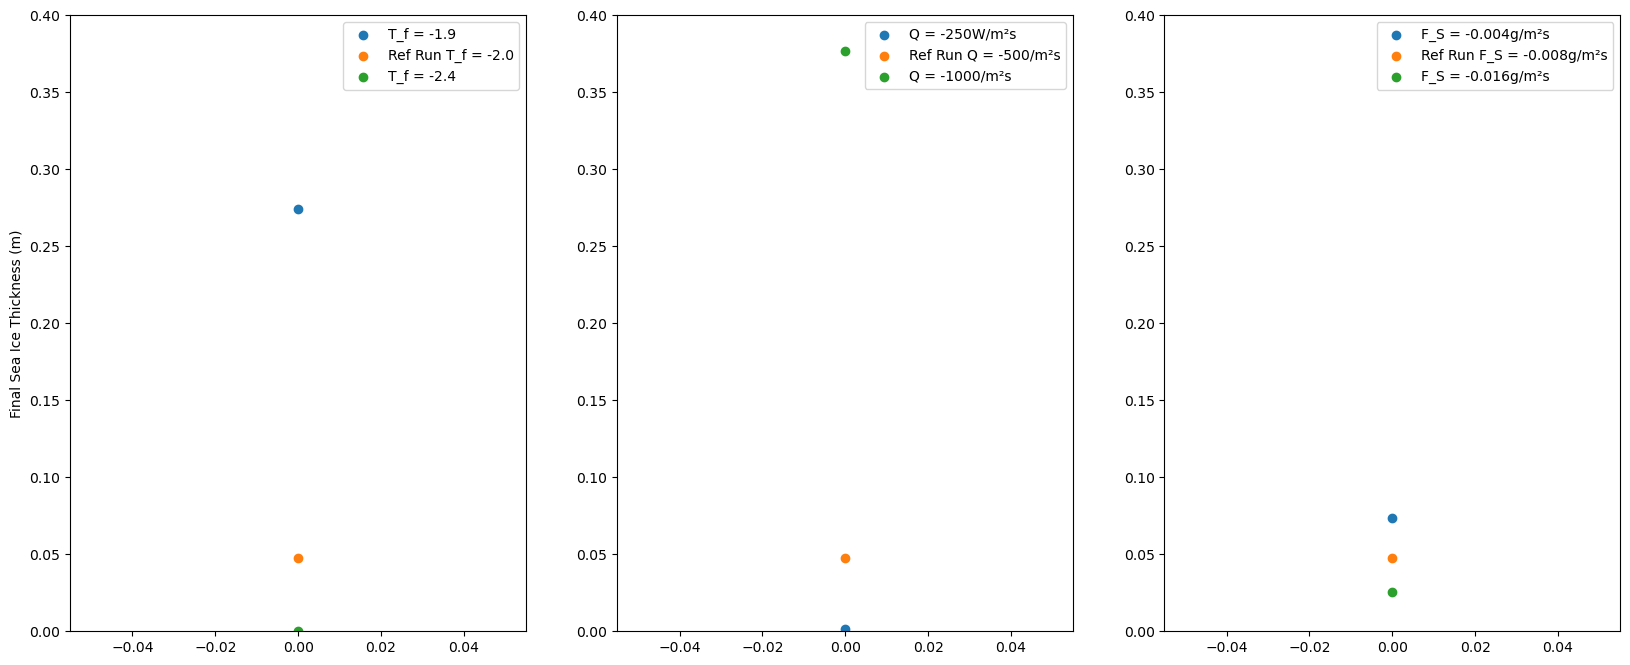

In [54]:
# plot ice

fig, axs = plt.subplots(1,3, figsize=(20,8), sharey = False)

# supercooling variation
axs[0].scatter(0, heat_ice_df.loc["h_ice (m)", "MIZ014"], label = "T_f = -1.9")
axs[0].scatter(0, heat_ice_df.loc["h_ice (m)", "MIZ009"], label = "Ref Run T_f = -2.0")
axs[0].scatter(0, heat_ice_df.loc["h_ice (m)", "MIZ015"], label = "T_f = -2.4")
axs[0].set_ylabel("Final Sea Ice Thickness (m)")

# heat flux variations
axs[1].scatter(0, heat_ice_df.loc["h_ice (m)", "MIZ010"], label = "Q = -250W/m²s")
axs[1].scatter(0, heat_ice_df.loc["h_ice (m)", "MIZ009"], label = "Ref Run Q = -500/m²s")
axs[1].scatter(0, heat_ice_df.loc["h_ice (m)", "MIZ011"], label = "Q = -1000/m²s")

# salt flux variations
axs[2].scatter(0, heat_ice_df.loc["h_ice (m)", "MIZ012"], label = "F_S = -0.004g/m²s")
axs[2].scatter(0, heat_ice_df.loc["h_ice (m)", "MIZ009"], label = "Ref Run F_S = -0.008g/m²s")
axs[2].scatter(0, heat_ice_df.loc["h_ice (m)", "MIZ013"], label = "F_S = -0.016g/m²s")

for ax in axs:
    ax.legend()
    ax.set_ylim(0,0.4)




Text(0.5, 1.0, 'Final Mean Sea Ice Thickness')

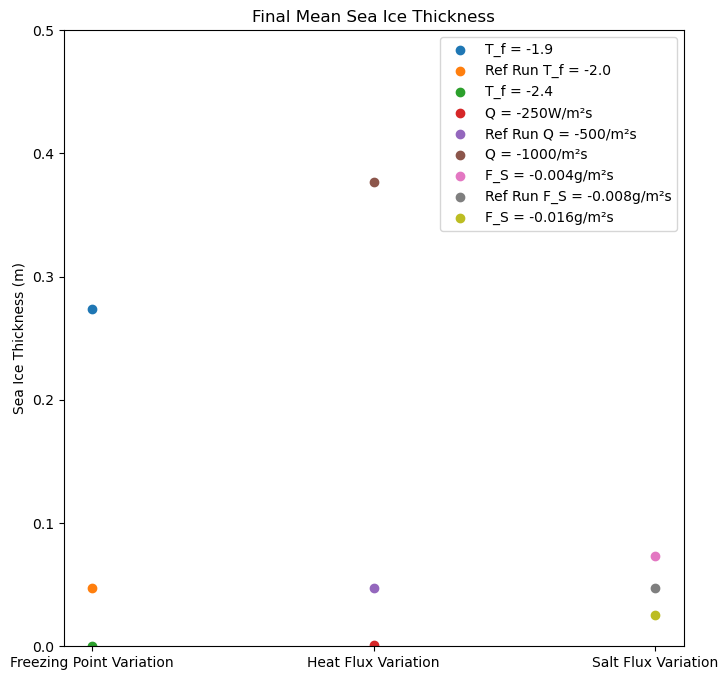

In [62]:
# plot ice

fig, ax = plt.subplots(figsize=(8,8))

# supercooling variation
ax.scatter(0, heat_ice_df.loc["h_ice (m)", "MIZ014"], label = "T_f = -1.9")
ax.scatter(0, heat_ice_df.loc["h_ice (m)", "MIZ009"], label = "Ref Run T_f = -2.0")
ax.scatter(0, heat_ice_df.loc["h_ice (m)", "MIZ015"], label = "T_f = -2.4")


# heat flux variations
ax.scatter(1, heat_ice_df.loc["h_ice (m)", "MIZ010"], label = "Q = -250W/m²s")
ax.scatter(1, heat_ice_df.loc["h_ice (m)", "MIZ009"], label = "Ref Run Q = -500/m²s")
ax.scatter(1, heat_ice_df.loc["h_ice (m)", "MIZ011"], label = "Q = -1000/m²s")

# salt flux variations
ax.scatter(2, heat_ice_df.loc["h_ice (m)", "MIZ012"], label = "F_S = -0.004g/m²s")
ax.scatter(2, heat_ice_df.loc["h_ice (m)", "MIZ009"], label = "Ref Run F_S = -0.008g/m²s")
ax.scatter(2, heat_ice_df.loc["h_ice (m)", "MIZ013"], label = "F_S = -0.016g/m²s")


ax.legend()
ax.set_ylim(0,0.5)
ax.set_ylabel("Sea Ice Thickness (m)")
ax.set_xticks([0, 1, 2], ['Freezing Point Variation', 'Heat Flux Variation', 'Salt Flux Variation'])
ax.set_title("Final Mean Sea Ice Thickness")


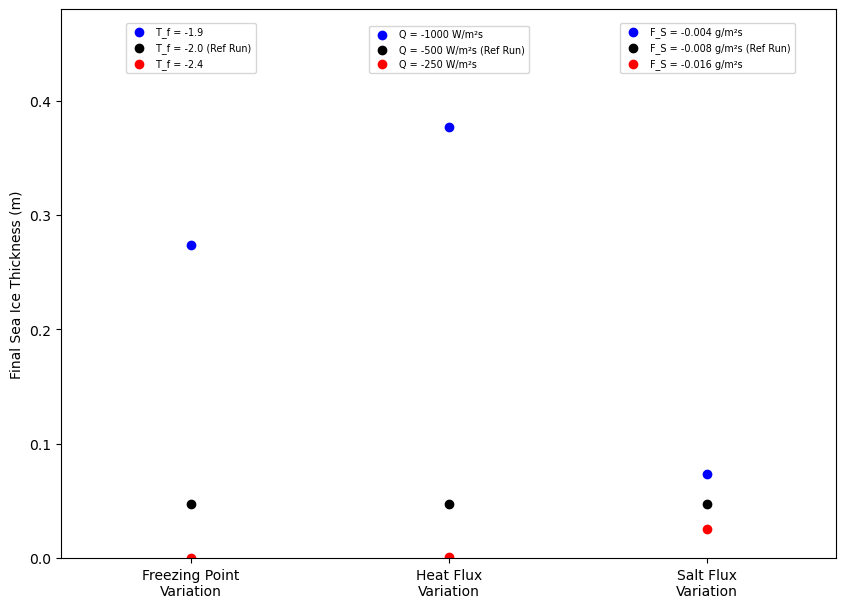

In [81]:



fig, ax = plt.subplots(figsize=(10, 9))
fig.subplots_adjust(top=0.72)          # leave room above the axes for 3 legends

# ---------- supercooling / freezing-point variation ----------
handles_fp = [
    ax.scatter(0, heat_ice_df.loc["h_ice (m)", "MIZ014"], label="T_f = -1.9", color = "blue"),
    ax.scatter(0, heat_ice_df.loc["h_ice (m)", "MIZ009"], label="T_f = -2.0 (Ref Run)", color = "black"),
    ax.scatter(0, heat_ice_df.loc["h_ice (m)", "MIZ015"], label="T_f = -2.4", color = "red"),
]

# ---------- heat-flux variation ----------
handles_hf = [
    ax.scatter(1, heat_ice_df.loc["h_ice (m)", "MIZ011"], label="Q = -1000 W/m²s", color = "blue"),
    ax.scatter(1, heat_ice_df.loc["h_ice (m)", "MIZ009"], label="Q = -500 W/m²s (Ref Run)", color = "black"),
    ax.scatter(1, heat_ice_df.loc["h_ice (m)", "MIZ010"], label="Q = -250 W/m²s", color = "red"),
]

# ---------- salt-flux variation ----------
handles_sf = [
    ax.scatter(2, heat_ice_df.loc["h_ice (m)", "MIZ012"], label="F_S = -0.004 g/m²s", color = "blue"),
    ax.scatter(2, heat_ice_df.loc["h_ice (m)", "MIZ009"], label="F_S = -0.008 g/m²s (Ref Run)", color = "black"),
    ax.scatter(2, heat_ice_df.loc["h_ice (m)", "MIZ013"], label="F_S = -0.016 g/m²s", color = "red"),
]

ax.set_ylim(0, 0.48)
ax.set_xlim(-0.5, 2.5)
ax.set_ylabel("Final Sea Ice Thickness (m)")
ax.set_xticks([0, 1, 2],
              ['Freezing Point\nVariation', 'Heat Flux\nVariation', 'Salt Flux\nVariation'])
              #['Freezing Point\nVariation', 'Heat Flux\nVariation', 'Salt Flux\nVariation'])

# ---------- one legend per group, anchored in data coords ----------
leg_kw = dict(loc="lower center", fontsize="x-small",
              title_fontsize="small", frameon=True, fancybox=True)

leg1 = Legend(ax, handles_fp, [h.get_label() for h in handles_fp],
              title=None, #"Freezing Point Variation"
              bbox_to_anchor=(0, 0.42), bbox_transform=ax.transData, **leg_kw)
ax.add_artist(leg1)

leg2 = Legend(ax, handles_hf, [h.get_label() for h in handles_hf],
              title=None, #"Heat Flux Variation"
              bbox_to_anchor=(1, 0.42), bbox_transform=ax.transData, **leg_kw)
ax.add_artist(leg2)

leg3 = Legend(ax, handles_sf, [h.get_label() for h in handles_sf],
              title=None, # "Salt Flux Variation"
              bbox_to_anchor=(2, 0.42), bbox_transform=ax.transData, **leg_kw)
ax.add_artist(leg3)

plt.show()